# Exploratory Data Analysis
In this phase of EDA, we will analyze the resultant table to gain insights into the distrinution of each column.
This will help understand data patterns, identify anomalies and ensure quality before further analysis.

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats

# Loading Dataset

In [2]:
# database connection
conn = sqlite3.connect('inventory.db')

# fetch vendor summary data
df = pd.read_sql("SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


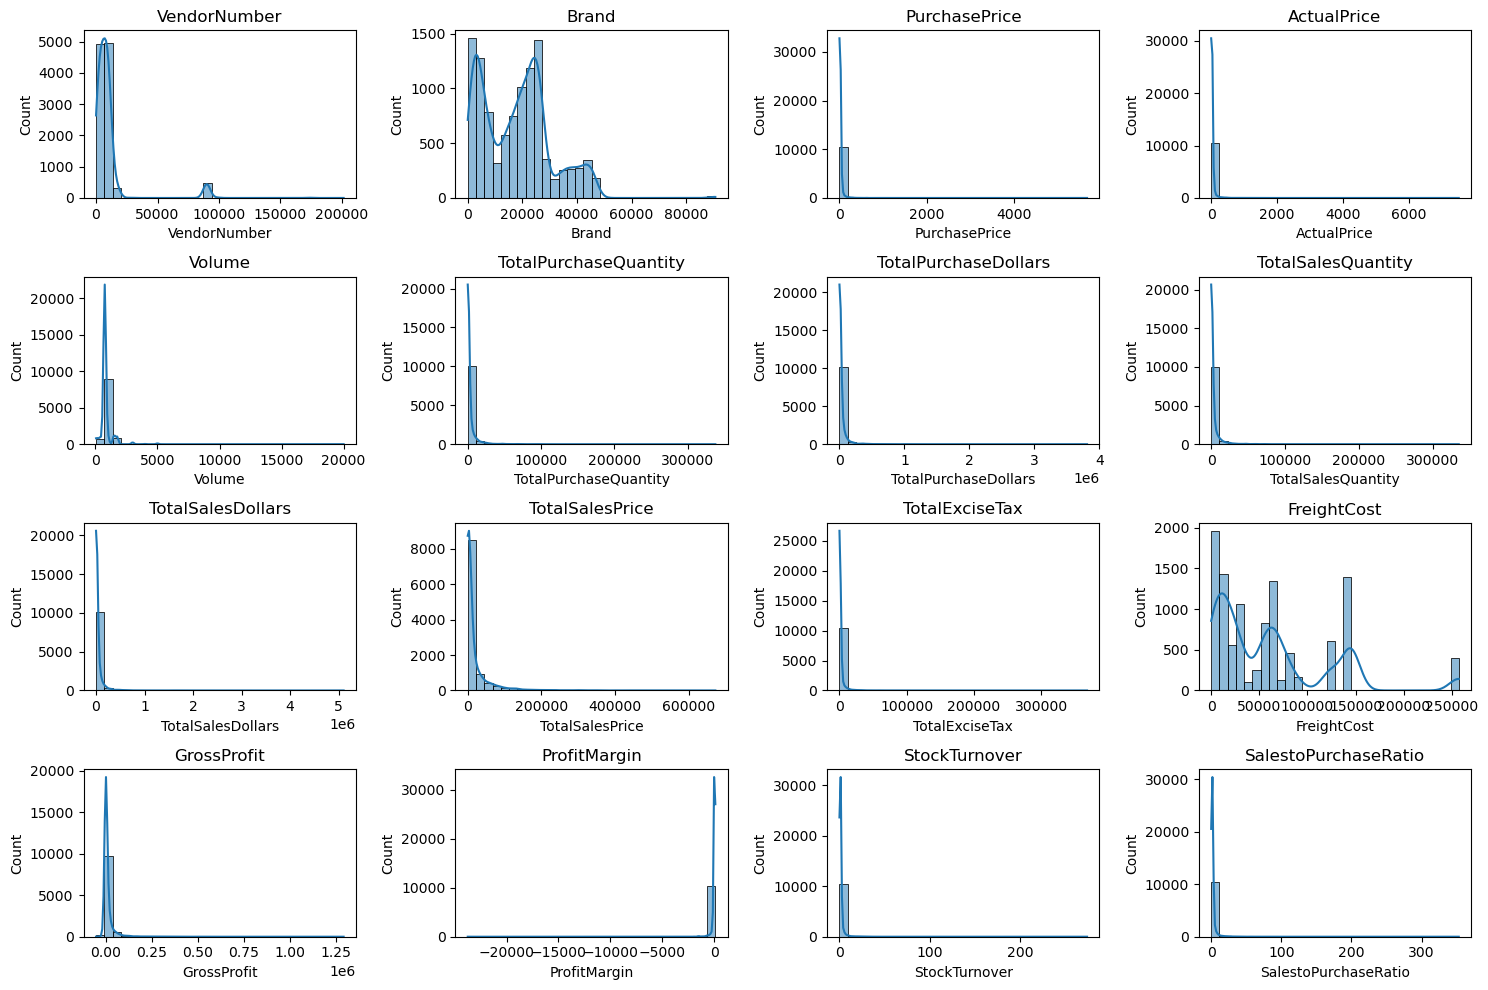

In [4]:
# Distribution plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

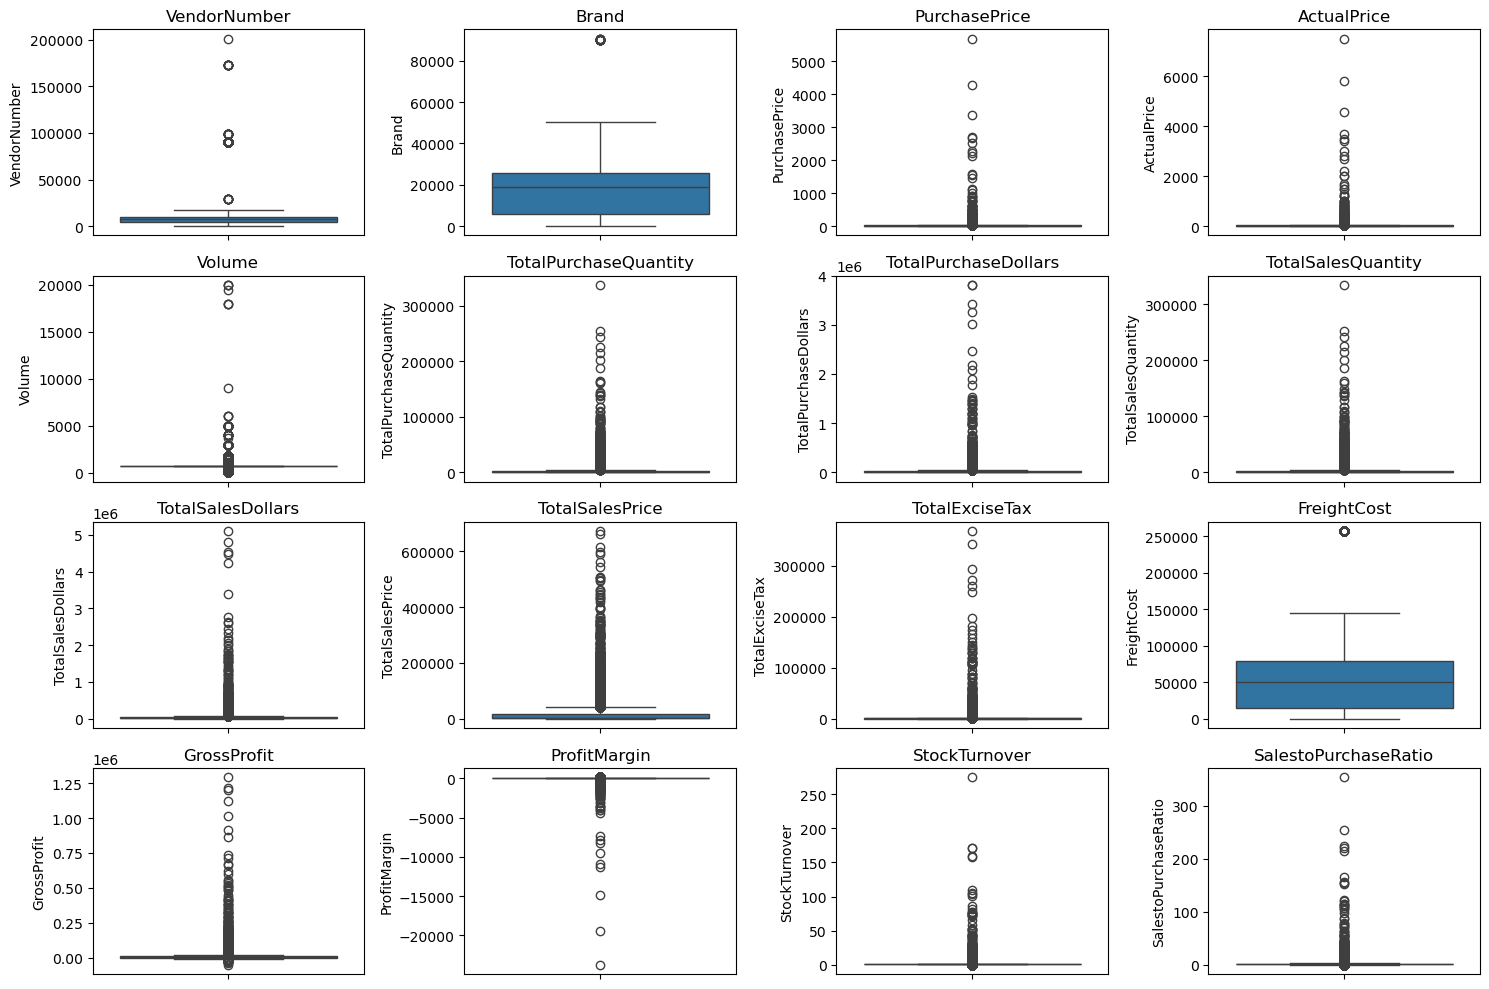

In [5]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()    

#### Negative & Zero Values:
* Gross Profit: Minimum values is -52,002.78, indicating losses. Some products or transactions maybe selling at a loss due to high costs or selling at discounts lower than the purchase price.
* Profit Margin: Has a minimum of -inf, which suggests cases where revenue is zero or lower than costs.
* Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

#### Outliers Indicated by High Standard Deviation:
* Purchase & Actual Prices: The max values (5,681.81 & 7,4999.99) are significantly are higher than the mean (24.39 & 35.64), indicating potential premium products.
* Freight Cost: Huge variation from 0.09 to 257,032 suggests logistics inefficiencies or bulk shipments.
* Stock Turnover: Ranges from 0 to 274.5 indicating that some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.
  

In [6]:
df = pd.read_sql("""SELECT *
    FROM vendor_sales_summary
    WHERE GrossProfit > 0
    AND ProfitMargin > 0
    AND TotalSalesQuantity > 0""", conn)

In [7]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,8564.0,10107.074965,17635.714818,2.000000,3664.000000,7153.000000,9552.000000,2.013590e+05
Brand,8564.0,17614.670131,12946.130933,58.000000,5375.750000,17606.000000,24935.250000,9.063100e+04
PurchasePrice,8564.0,21.780897,81.189624,0.360000,6.660000,10.060000,17.850000,3.352930e+03
ActualPrice,8564.0,32.297467,112.420744,0.490000,9.990000,14.990000,25.990000,4.559990e+03
Volume,8564.0,864.332263,724.240079,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,8564.0,3772.008991,12276.960631,1.000000,42.000000,431.000000,2666.750000,3.376600e+05
TotalPurchaseDollars,8564.0,35887.253324,136722.999153,0.710000,546.187500,5018.400000,26610.177500,3.811252e+06
TotalSalesQuantity,8564.0,3748.983419,12125.696083,1.000000,62.000000,490.500000,2675.000000,3.349390e+05
TotalSalesDollars,8564.0,51542.278077,186071.489729,1.980000,1355.580000,8483.780000,40622.112500,5.101920e+06
TotalSalesPrice,8564.0,22759.270732,49305.274018,0.990000,584.790000,4549.755000,22595.252500,6.728193e+05


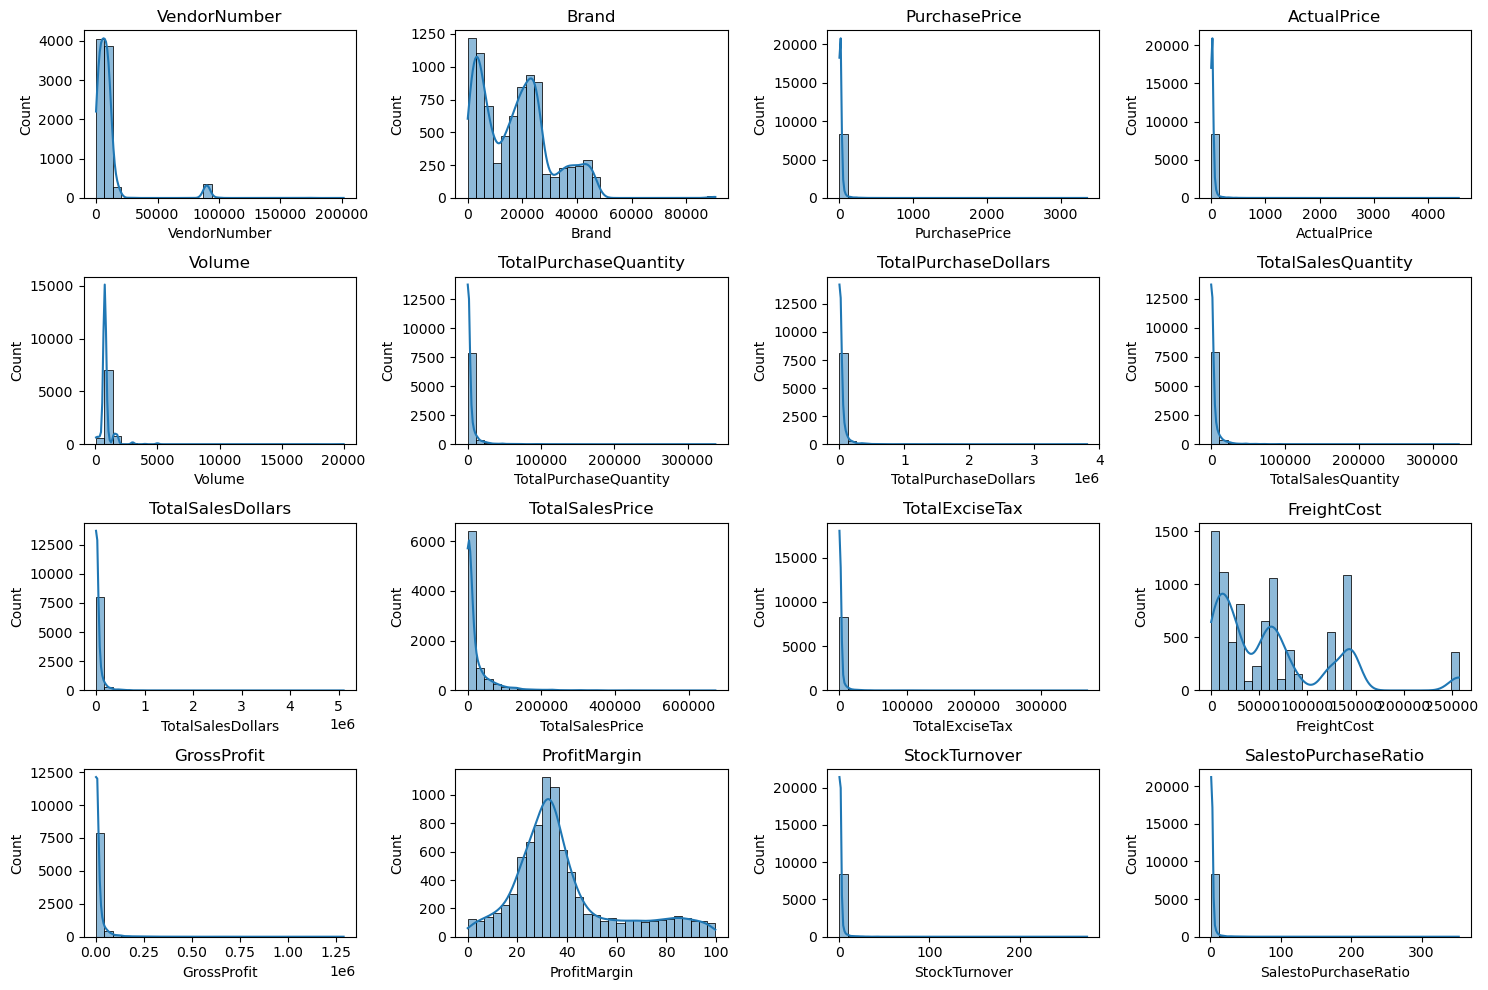

In [9]:
# Distribution plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

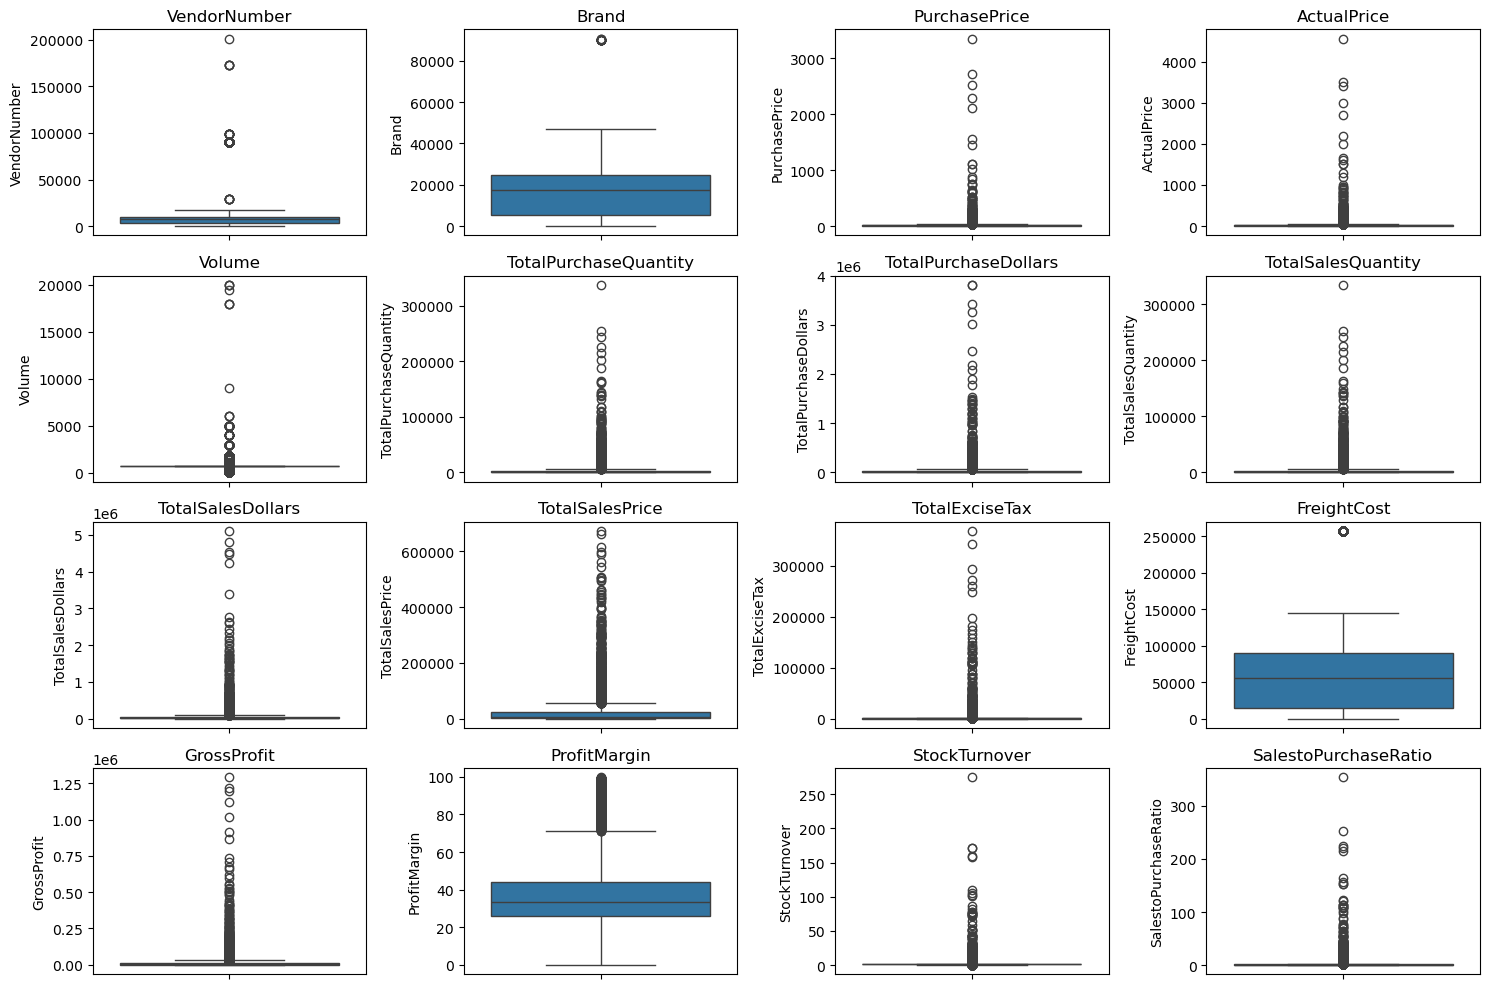

In [10]:
# Outlier Detection with Boxplots
plt.figure(figsize=(15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()    

### Top 10 Vendors

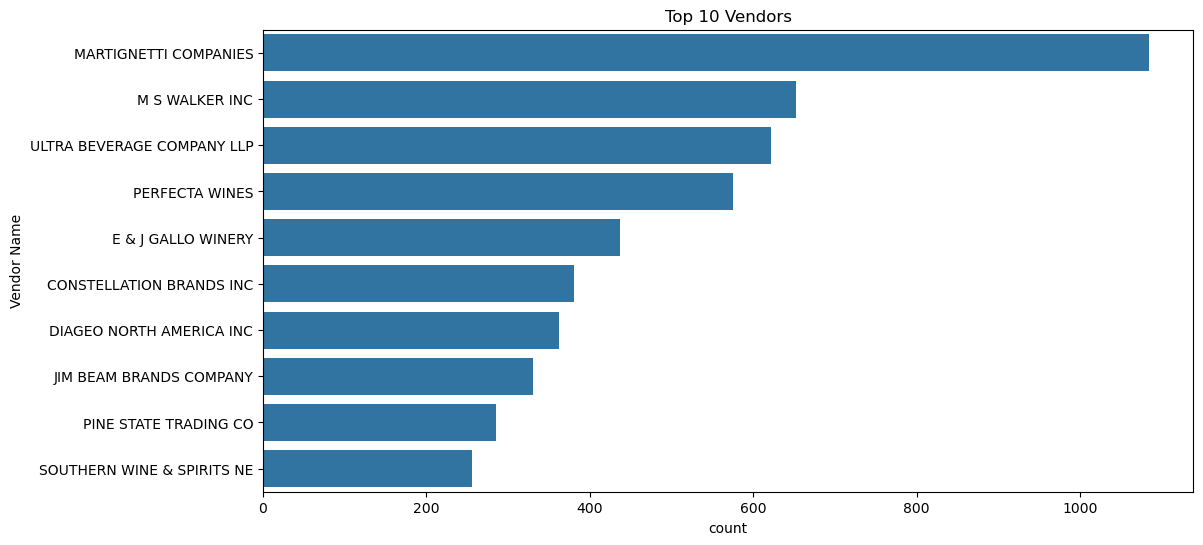

In [11]:
top_10_vendors = df['VendorName'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.countplot(data=df, y='VendorName', order=top_10_vendors)
plt.title("Top 10 Vendors")
plt.xlabel('count')
plt.ylabel('Vendor Name')
plt.show()

### Top 10 Products

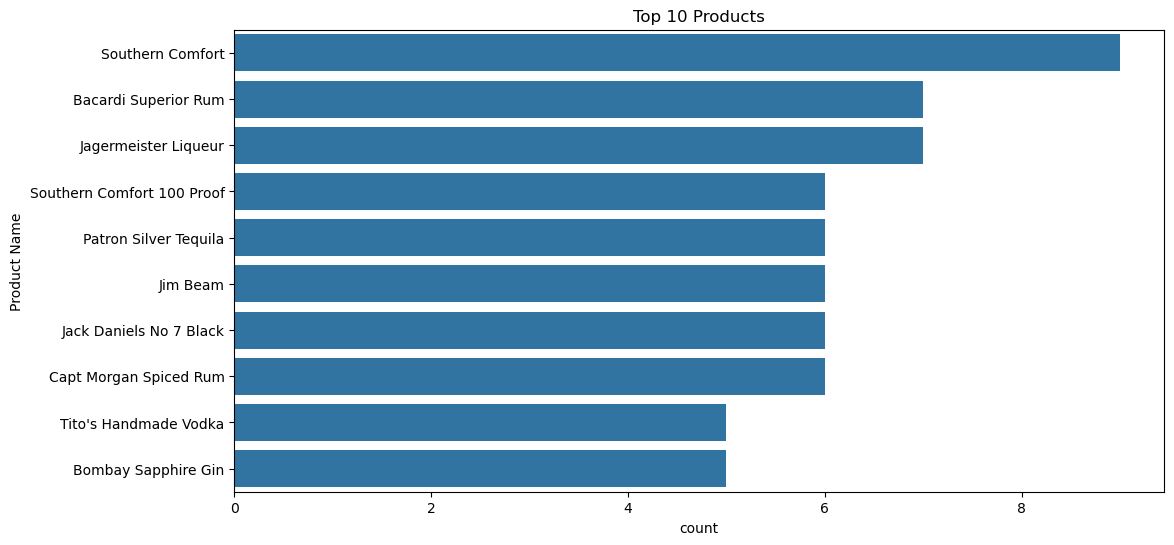

In [12]:
top_10_product = df['Description'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.countplot(data=df, y='Description', order=top_10_product)
plt.title("Top 10 Products")
plt.xlabel('count')
plt.ylabel('Product Name')
plt.show()

## Correlation between Numerical columns

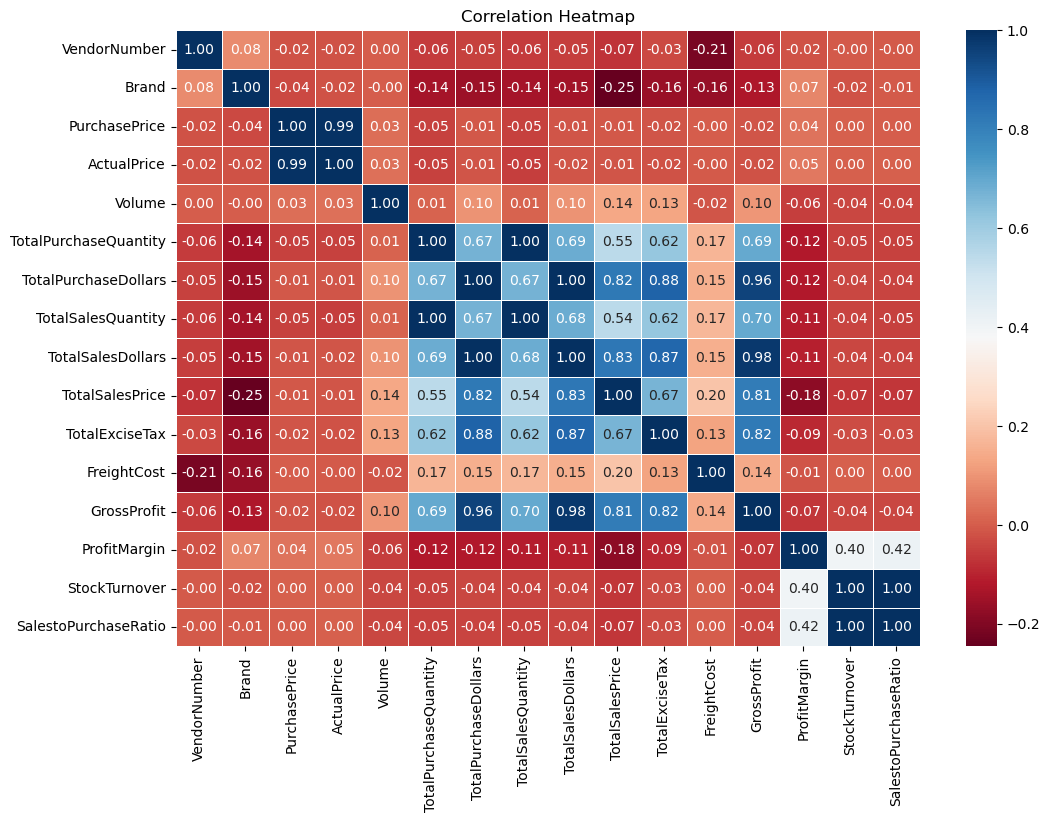

In [13]:
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="RdBu", linewidths=0.5 )
plt.title("Correlation Heatmap")
plt.show()

* PurchasePrice has weak correlation with TotalSalesDollars, suggesting price variations do not significantly impact sales or revenue.
* PurhasePrice has weak correlation with GrossProfit, suggesting that GrossProfit is not affected by pricing variations.
* TotalPurchaseQuantity and TotalSalesQuantity are perfectly correlated (1.00). This suggests very little unsold inventory in the aggregated data, nearly every purchased item is eventually sold.
* Profit Margin exhibits a weak negative correlation (-0.18) with TotalSalesPrice, indicating that higher-priced sales are associated with slightly lower margin percentages. This may reflect competitive pricing, bulk discounts, or lower percentage markups on premium products.
* StockTurnover has negative correlation with GrossProfit (-0.04) and moderate correlation with ProfitMargin (0.40), indicating that faster turnover doesnot necessarily result in higher profits.

# Data Analysis

### Q1. Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins

In [14]:
df.shape

(8564, 18)

In [15]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}
).reset_index()

In [16]:
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [17]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [18]:
low_sales_threshold

np.float64(560.299)

In [19]:
high_margin_threshold

np.float64(64.97017552750113)

In [20]:
# Filtering for brands whose sales are lesser but margins high
target_brands = brand_performance[(brand_performance['TotalSalesDollars'] <= low_sales_threshold) & 
                                  (brand_performance['ProfitMargin'] >= high_margin_threshold)]

print("Brands who need Promotional or Pricing Adjustments:")
display(target_brands.sort_values(by='TotalSalesDollars'))

Brands who need Promotional or Pricing Adjustments:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


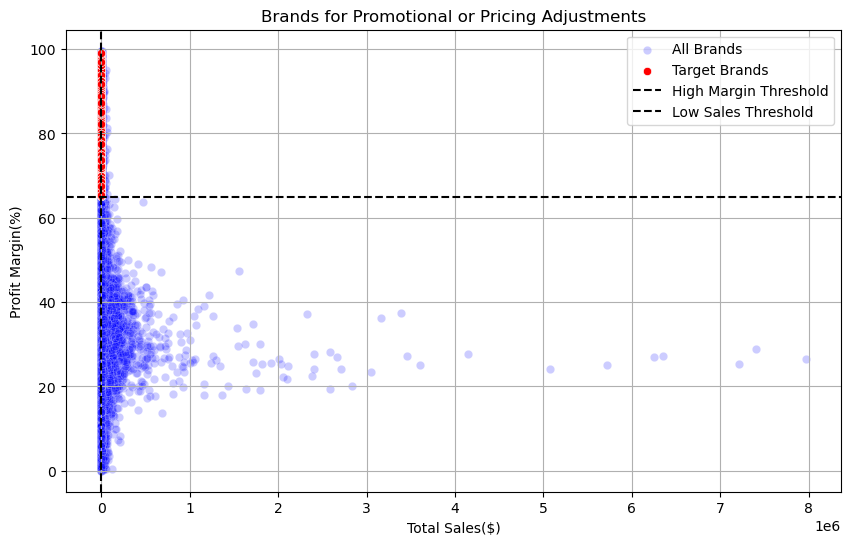

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color='Blue', label='All Brands', alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color='red', label='Target Brands')

plt.axhline(high_margin_threshold, linestyle='--', color='black', label='High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle='--', color='black', label='Low Sales Threshold')

plt.xlabel('Total Sales($)')
plt.ylabel('Profit Margin(%)')
plt.title('Brands for Promotional or Pricing Adjustments')
plt.legend()
plt.grid()
plt.show()


#### *To visualize it clearly filtering All brands*

In [22]:
brand_performance_visual = brand_performance[brand_performance['TotalSalesDollars'] <10000]

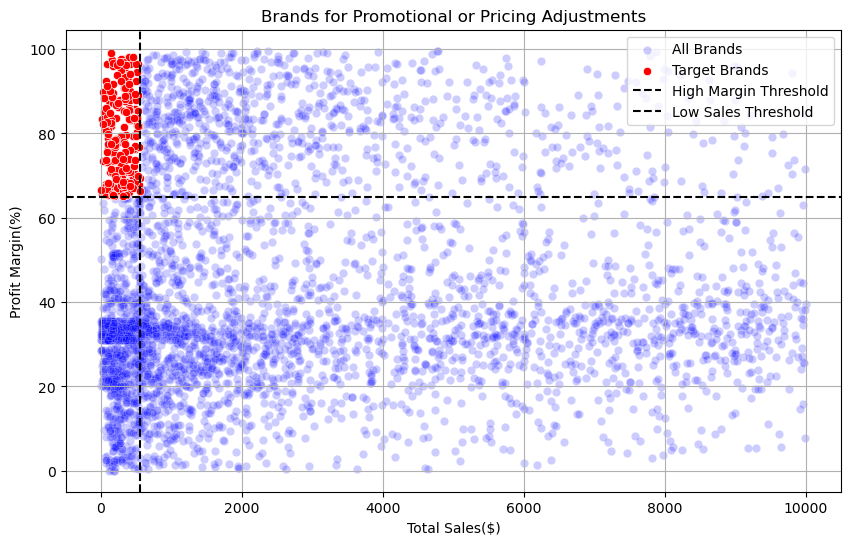

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance_visual, x='TotalSalesDollars', y='ProfitMargin', color='Blue', label='All Brands', alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color='red', label='Target Brands')

plt.axhline(high_margin_threshold, linestyle='--', color='black', label='High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle='--', color='black', label='Low Sales Threshold')

plt.xlabel('Total Sales($)')
plt.ylabel('Profit Margin(%)')
plt.title('Brands for Promotional or Pricing Adjustments')
plt.legend()
plt.grid()
plt.show()


### Q2. Which vendors and brands demonstrate the highest sales performance ?

In [70]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >=1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [25]:
top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)

In [26]:
top_brands_f = top_brands.apply(lambda x: format_dollars(x))

In [27]:
top_vendors_f = top_vendors.apply(lambda x: format_dollars(x))
top_vendors_f

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollars, dtype: object

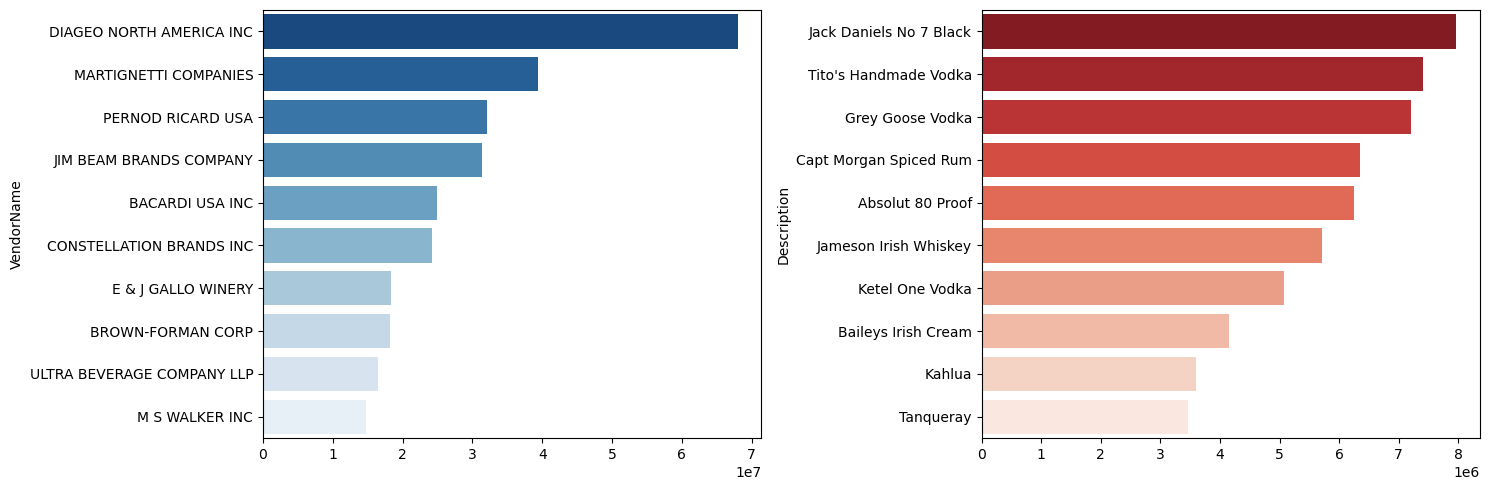

In [28]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, hue=top_vendors.index, palette="Blues_r")

plt.subplot(1,2,2)
ax2 = sns.barplot(y=top_brands.index, x=top_brands.values, hue=top_brands.index, palette='Reds_r')
plt.tight_layout()
plt.show()

### Q3. Which vendors contribute the most to total purchase dollars ?

In [29]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [30]:
vendor_performance['PurchaseContribution(%)'] = round((vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()) *100,2)

In [31]:
vendor_performance = round(vendor_performance.sort_values(by='PurchaseContribution(%)', ascending=False), 2)

In [32]:
top_vendor_contri = vendor_performance.head(10).copy()
top_vendor_contri['TotalSalesDollars'] = top_vendor_contri['TotalSalesDollars'].apply(format_dollars)
top_vendor_contri['TotalPurchaseDollars'] = top_vendor_contri['TotalPurchaseDollars'].apply(format_dollars)
top_vendor_contri['GrossProfit'] = top_vendor_contri['GrossProfit'].apply(format_dollars)

In [33]:
top_vendor_contri['Cumulative_Contibution'] = top_vendor_contri['PurchaseContribution(%)'].cumsum()

In [34]:
top_vendor_contri

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution(%),Cumulative_Contibution
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


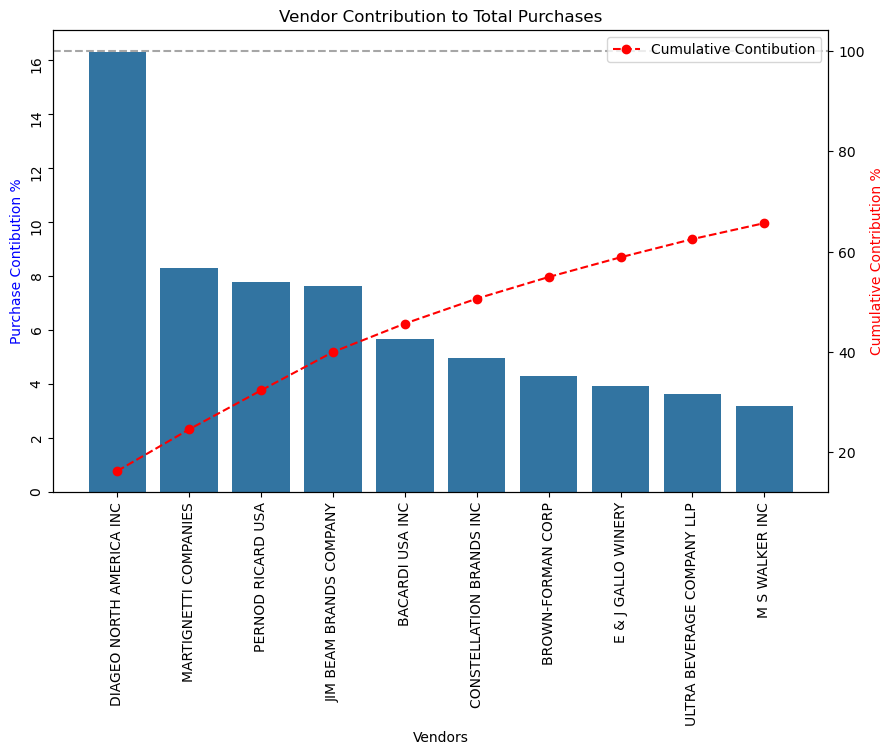

In [35]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Bar Plot for purchase contribution
sns.barplot(x=top_vendor_contri['VendorName'], y=top_vendor_contri['PurchaseContribution(%)'], ax=ax1)

# Line Plot for cumulative contribution
ax2 = ax1.twinx()
ax2.plot(top_vendor_contri['VendorName'], top_vendor_contri['Cumulative_Contibution'], color='red', marker='o', linestyle='dashed', label='Cumulative Contibution')

ax1.tick_params(rotation=90)
ax1.set_ylabel('Purchase Contibution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')
plt.show()

### Q4. Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings ?

In [36]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [37]:
df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'], q=3, labels=['Small', 'Medium', 'Large'])

In [38]:
df.groupby('OrderSize', observed=True )[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


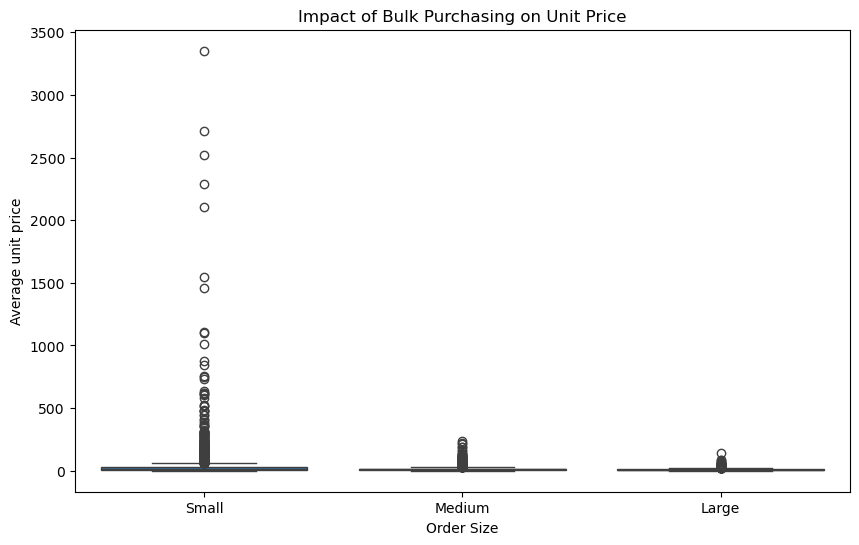

In [39]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average unit price")
plt.show()

* Vendors buying in bulk get the lowest unit price ($10.78 per unit).
* The price difference between small and large order is substantial.
* This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes.

### Q5. Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [40]:
df[df['StockTurnover'] < 1].groupby('VendorName')[['StockTurnover']].mean().sort_values(by='StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


### Q6. How much capital is locked in unsold inventory per vendor and which vendors contibut the most of it?

In [71]:
df['UnsoldInventoryValue'] = (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity']) * df['PurchasePrice']
print("Total Unsold Capital: ", format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital:  2.71M


In [72]:
# Total Unsold value per vendor
inventory_per_vendor = df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()
inventory_per_vendor = inventory_per_vendor.sort_values(by='UnsoldInventoryValue', ascending=False)
inventory_per_vendor['UnsoldInventoryValue'] = inventory_per_vendor['UnsoldInventoryValue'].apply(format_dollars)

In [73]:
inventory_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


### Q7. What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors ?

In [80]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

In [81]:
top_threshold, low_threshold

(np.float64(40622.1125), np.float64(1355.58))

In [89]:
top_vendors_margin = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors_margin = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

In [90]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [92]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors_margin)
low_mean, low_lower, low_upper = confidence_interval(low_vendors_margin)

print(f'Top vendors 95% CI: ({top_lower:.2f}), ({top_upper:.2f}), Mean: {top_mean:.2f}')
print(f'Low vendors 95% CI: ({low_lower:.2f}), ({low_upper:.2f}), Mean: {low_mean:.2f}')

Top vendors 95% CI: (30.74), (31.61), Mean: 31.18
Low vendors 95% CI: (40.50), (42.64), Mean: 41.57


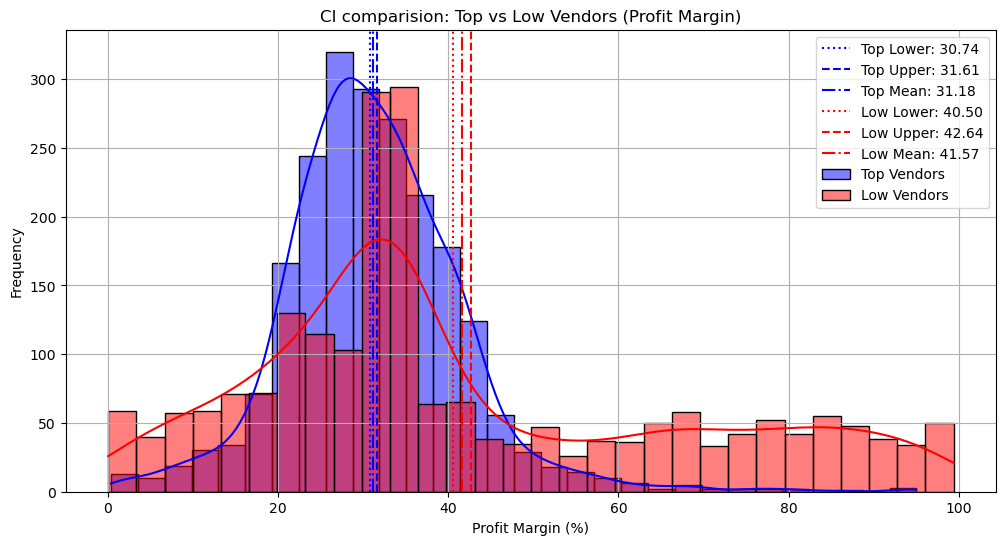

In [101]:
plt.figure(figsize=(12,6))

# Top vendors plot
sns.histplot(top_vendors_margin, kde=True, color='blue', bins=30, alpha=0.5, label='Top Vendors')
plt.axvline(top_lower, color='blue', linestyle=':', label=f'Top Lower: {top_lower:.2f}')
plt.axvline(top_upper, color='blue', linestyle='--', label=f'Top Upper: {top_upper:.2f}')
plt.axvline(top_mean, color='blue', linestyle='-.', label=f'Top Mean: {top_mean:.2f}')

# Low vendors plot
sns.histplot(low_vendors_margin, kde=True, color='red', bins=30, alpha=0.5, label='Low Vendors')
plt.axvline(low_lower, color='red', linestyle=':', label=f'Low Lower: {low_lower:.2f}')
plt.axvline(low_upper, color='red', linestyle='--', label=f'Low Upper: {low_upper:.2f}')
plt.axvline(low_mean, color='red', linestyle='-.', label=f'Low Mean: {low_mean:.2f}')

plt.title("CI comparision: Top vs Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

* The CI for low-performing vendors is significantly higher than that of top-performing vendors.
* This suggests that vendors with lower sales tend to maintain higher profit margins.

### Q8. Is there a signinficant profit margins between top-performing and low-performing vendors ?

Hypothesis:

$H_o$ (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

$H_1$ (Alternative Hypothesis): There is significant difference in the mean profit margins of top-performing and low-performing vendors.

In [104]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25) 

top_vendors_margin = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors_margin = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

# Two-sample T-test
t_stat, p_value = ttest_ind(top_vendors_margin, low_vendors_margin, equal_var=False)

# Print results 
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value <0.05:
    print("Reject Ho: There is signinficant difference in the mean profit margins of top-performing and low-performing vendors.")
else:
    print("Fail to Reject Ho: No significant difference in profit margins.")

T-Statistic: -17.6695, P-Value: 0.0000
Reject Ho: There is signinficant difference in the mean profit margins of top-performing and low-performing vendors.
